In [1]:
KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_index", "right_index",
    "left_thumb", "right_thumb",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_heel", "right_heel",
    "left_foot_index", "right_foot_index"
]

# graph edges
EDGES = [
    (0,1), (0,2),                     # nose -> eyes
    (3,4),       # shoulders
    (3,5), (5,7), (7,9),       # left arm
    (4,6), (6,8), (8,10),      # right arm
    (13,14),               # hips
    (13,15), (15,17),         # left leg
    (14,16), (16,18),         # right leg
    (19,21), (20,22)                   # feet
]


In [2]:
import numpy as np

def normalize_pose(points):
    """
    points: np.array shape (23, 2)
    """

    pts = points.copy().astype(float)

    mean_x = np.nanmean(pts[:,0])
    mean_y = np.nanmean(pts[:,1])
    pts[:,0] = np.nan_to_num(pts[:,0], nan=mean_x)
    pts[:,1] = np.nan_to_num(pts[:,1], nan=mean_y)



    # centre
    left_hip = pts[13]
    right_hip = pts[14]
    root = (left_hip + right_hip) / 2
    pts -= root

    # scale
    left_sh = pts[3]
    right_sh = pts[4]
    shoulder_dist = np.linalg.norm(left_sh - right_sh)

    if shoulder_dist < 1e-6:
        shoulder_dist = 1e-6

    pts /= shoulder_dist

    # orientation
    dx = right_sh[0] - left_sh[0]
    dy = right_sh[1] - left_sh[1]
    theta = np.arctan2(dy, dx)

    R = np.array([
        [ np.cos(theta),  np.sin(theta)],
        [-np.sin(theta),  np.cos(theta)]
    ])

    pts = pts @ R.T

    # sides
    if pts[4, 0] < pts[3, 0]:
        pts[:,0] *= -1

    return pts

def angle(a, b, c):
    v1 = a - b
    v2 = c - b
    cosang = np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2) + 1e-6)
    return np.arccos(np.clip(cosang, -1, 1))

In [3]:
def build_node_features(norm_pose):
    feats = []

    for i in range(len(norm_pose)):
        x, y = norm_pose[i]

        parent = None
        for (a,b) in EDGES:
            if b == i:
                parent = a
                break

        if parent is not None:
            rel = norm_pose[i] - norm_pose[parent]
            dist = np.linalg.norm(rel)
        else:
            rel = np.zeros(2)
            dist = 0.0

        ang = 0.0
        if i in [5,6,15,16]: 
            if i == 5: ang = angle(norm_pose[3], norm_pose[5], norm_pose[7])
            if i == 6: ang = angle(norm_pose[4], norm_pose[6], norm_pose[8])
            if i == 15: ang = angle(norm_pose[13], norm_pose[15], norm_pose[17])
            if i == 16: ang = angle(norm_pose[14], norm_pose[16], norm_pose[18])

        feats.append([x, y, rel[0], rel[1], dist, ang])

    return np.array(feats)

def build_edge_features(norm_pose):
    feats = []
    for (i,j) in EDGES:
        rel = norm_pose[j] - norm_pose[i]
        dist = np.linalg.norm(rel)
        feats.append([rel[0], rel[1], dist])
    return np.array(feats)


In [4]:
import matplotlib.pyplot as plt

def plot_pose(points, edges, title="Pose"):
    plt.figure(figsize=(5,5))
    for (i,j) in edges:
        if not np.any(np.isnan(points[i])) and not np.any(np.isnan(points[j])):
            plt.plot([points[i,0], points[j,0]],
                     [points[i,1], points[j,1]], 'k-', linewidth=2)

    plt.scatter(points[:,0], points[:,1], c='red', s=40)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis('equal')
    plt.show()


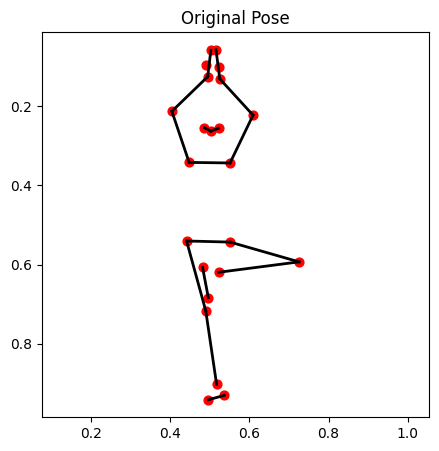

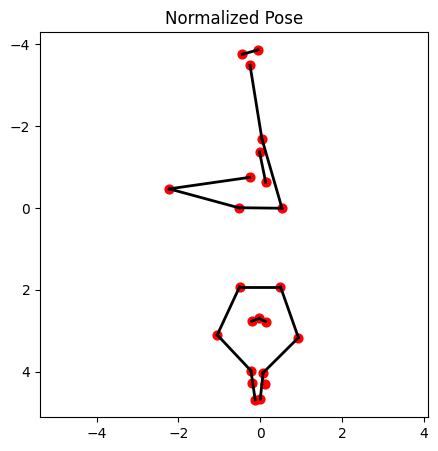

In [5]:

example_pose = np.array([
      [
        0.5024232633279483,
        0.2625
      ],
      [
        0.5218093699515347,
        0.25555555555555554
      ],
      [
        0.4862681744749596,
        0.25416666666666665
      ],
      [
        0.5508885298869144,
        0.34305555555555556
      ],
      [
        0.44749596122778673,
        0.3416666666666667
      ],
      [
        0.6090468497576736,
        0.2222222222222222
      ],
      [
        0.40387722132471726,
        0.2125
      ],
      [
        0.5250403877221325,
        0.13055555555555556
      ],
      [
        0.49434571890145396,
        0.125
      ],
      [
        0.5153473344103393,
        0.05694444444444444
      ],
      [
        0.5024232633279483,
        0.058333333333333334
      ],
      [
        0.5218093699515347,
        0.1
      ],
      [
        0.4911147011308562,
        0.09583333333333334
      ],
      [
        0.5508885298869144,
        0.5430555555555555
      ],
      [
        0.4410339256865913,
        0.5402777777777777
      ],
      [
        0.7253634894991923,
        0.5930555555555556
      ],
      [
        0.4894991922455573,
        0.7166666666666667
      ],
      [
        0.5218093699515347,
        0.6194444444444445
      ],
      [
        0.5169628432956381,
        0.9027777777777778
      ],
      [
        0.481421647819063,
        0.6069444444444444
      ],
      [
        0.5363489499192245,
        0.9305555555555556
      ],
      [
        0.49596122778675283,
        0.6833333333333333
      ],
      [
        0.49596122778675283,
        0.9416666666666667
      ]
    ])
  

plot_pose(example_pose, EDGES, title="Original Pose")

norm_pose = normalize_pose(example_pose)

plot_pose(norm_pose, EDGES, title="Normalized Pose")


In [6]:
import pandas as pd



def process_csv_for_gcn(csv_path, output_npz="gcn_dataset_test.npz"):
    df = pd.read_csv(csv_path)

    node_features = []
    edge_features = []
    labels = []
    img_names = []

    for idx, row in df.iterrows():
        pts = []
        for name in KEYPOINT_NAMES:
            pts.append([row[f"{name}_x"], row[f"{name}_y"]])
        pts = np.array(pts, dtype=float)

        norm_pts = normalize_pose(pts)
        img_names.append(row["img_name"])

        nf = build_node_features(norm_pts)
        ef = build_edge_features(norm_pts)

        node_features.append(nf)
        edge_features.append(ef)
        labels.append(row["class"])

    np.savez(output_npz,
             node_features=np.array(node_features),
             edge_features=np.array(edge_features),
             labels=np.array(labels),
             edges=np.array(EDGES), img_names=np.array(img_names))

    print(f"Saved GCN dataset to {output_npz}")

    return node_features, edge_features, labels


In [7]:
process_csv_for_gcn(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\test_data.csv", output_npz="gcn_dataset_test.npz")

process_csv_for_gcn(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\train_data.csv", output_npz="gcn_dataset_train.npz")

process_csv_for_gcn(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\valid_data.csv", output_npz="gcn_dataset_valid.npz")

Saved GCN dataset to gcn_dataset_test.npz
Saved GCN dataset to gcn_dataset_train.npz
Saved GCN dataset to gcn_dataset_valid.npz


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_10252\1524613087.py:10: RuntimeWarning: Mean of empty slice
  mean_x = np.nanmean(pts[:,0])
C:\Users\Ульяна\AppData\Local\Temp\ipykernel_10252\1524613087.py:11: RuntimeWarning: Mean of empty slice
  mean_y = np.nanmean(pts[:,1])


([array([[-2.62248619e-02,  2.70041739e+00,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [-2.12788948e-01,  2.77008933e+00, -1.86564086e-01,
           6.96719438e-02,  1.99149034e-01,  0.00000000e+00],
         [ 1.31079451e-01,  2.77890325e+00,  1.57304313e-01,
           7.84858644e-02,  1.75797263e-01,  0.00000000e+00],
         [-5.05354490e-01,  1.92773035e+00,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 4.94645510e-01,  1.92773035e+00,  1.00000000e+00,
          -2.22044605e-16,  1.00000000e+00,  0.00000000e+00],
         [-1.05205671e+00,  3.10375918e+00, -5.46702217e-01,
           1.17602883e+00,  1.29689133e+00,  1.95118719e+00],
         [ 9.33223198e-01,  3.17112272e+00,  4.38577688e-01,
           1.24339237e+00,  1.31847449e+00,  2.01384631e+00],
         [-2.27795759e-01,  3.97927529e+00,  8.24260948e-01,
           8.75516113e-01,  1.20247020e+00,  0.00000000e+00],
         [ 6.974

In [8]:
data = np.load("gcn_dataset_valid.npz", allow_pickle=True)

node_features = data["node_features"]
edge_features = data["edge_features"]
edges = data["edges"]
labels = data["labels"]


In [9]:
print(node_features.shape)
print(edge_features.shape)
print(edges.shape)
print(labels.shape)


(203, 23, 6)
(203, 16, 3)
(16, 2)
(203,)


In [10]:
train = np.load("gcn_dataset_train.npz", allow_pickle=True)
valid = np.load("gcn_dataset_valid.npz", allow_pickle=True)
test  = np.load("gcn_dataset_test.npz", allow_pickle=True)


labels = train["labels"]

print("Уникальные классы:", np.unique(labels))
print("Количество классов:", len(np.unique(labels)))


Уникальные классы: [0 1 2 3 4 5 6]
Количество классов: 7


In [11]:
from torch_geometric.data import Dataset
from torch_geometric.data import Data
import torch

class YogaGCNDataset(Dataset):
    def __init__(self, npz_path):
        super().__init__()
        data = np.load(npz_path, allow_pickle=True)
        self.node_features = data["node_features"]
        self.edge_features = data["edge_features"]
        self.edges = torch.tensor(data["edges"], dtype=torch.long).t().contiguous()
        self.labels = data["labels"]

    def len(self):
        return len(self.labels)

    def get(self, idx):
        x = torch.tensor(self.node_features[idx], dtype=torch.float)
        edge_attr = torch.tensor(self.edge_features[idx], dtype=torch.float)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        return Data(
            x=x,
            edge_index=self.edges,
            edge_attr=edge_attr,
            y=y
        )

from torch_geometric.loader import DataLoader

train_ds = YogaGCNDataset("gcn_dataset_train.npz")
valid_ds = YogaGCNDataset("gcn_dataset_valid.npz")
test_ds  = YogaGCNDataset("gcn_dataset_test.npz")




train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)


c:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
print("\nnode_features has NaN:", np.isnan(train["node_features"]).any())
print("edge_features has NaN:", np.isnan(train["edge_features"]).any())
print("labels:", np.unique(train["labels"]))

print("\nnode_features has NaN:", np.isnan(valid["node_features"]).any())
print("edge_features has NaN:", np.isnan(valid["edge_features"]).any())
print("labels:", np.unique(valid["labels"]))

print("\nnode_features has NaN:", np.isnan(test["node_features"]).any())
print("edge_features has NaN:", np.isnan(test["edge_features"]).any())
print("labels:", np.unique(test["labels"]))



node_features has NaN: False
edge_features has NaN: False
labels: [0 1 2 3 4 5 6]

node_features has NaN: True
edge_features has NaN: True
labels: [0 1 2 3 4 5 6]

node_features has NaN: False
edge_features has NaN: False
labels: [0 1 2 3 4 5 6]


In [13]:

node = valid["node_features"]
edge = valid["edge_features"]

bad_idx = np.unique(np.where(np.isnan(node))[0])
bad_idx2 = np.unique(np.where(np.isnan(edge))[0])

print(np.unique(np.concatenate([bad_idx, bad_idx2])))


[42]


In [14]:
good_mask = ~np.isnan(node).any(axis=(1,2))

node_fixed = node[good_mask]
edge_fixed = edge[good_mask]
labels_fixed = valid["labels"][good_mask]

np.savez("gcn_dataset_valid.npz",
         node_features=node_fixed,
         edge_features=edge_fixed,
         edges=valid["edges"],
         labels=labels_fixed)


In [15]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F


class YogaGCN(nn.Module):
    def __init__(self, in_channels, edge_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)
        self.conv2 = GCNConv(128, 128)
        self.conv3 = GCNConv(128, 128)
        self.lin1 = nn.Linear(128, 64)
        self.lin2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        x = self.lin1(x).relu()
        return self.lin2(x)


model = YogaGCN(in_channels=node_features.shape[-1],
                edge_dim=edge_features.shape[-1],
                num_classes=len(np.unique(labels)))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(200):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()

    print("epoch", epoch, "loss", loss.item())


epoch 0 loss 1.78961181640625
epoch 1 loss 1.7203668355941772
epoch 2 loss 1.6750773191452026
epoch 3 loss 1.5309573411941528
epoch 4 loss 1.5462628602981567
epoch 5 loss 2.203016519546509
epoch 6 loss 1.00601327419281
epoch 7 loss 1.1470842361450195
epoch 8 loss 1.2382659912109375
epoch 9 loss 0.9669704437255859
epoch 10 loss 1.253299355506897
epoch 11 loss 1.3761317729949951
epoch 12 loss 1.196772575378418
epoch 13 loss 1.2531105279922485
epoch 14 loss 1.1412687301635742
epoch 15 loss 1.322050929069519
epoch 16 loss 0.9611381888389587
epoch 17 loss 0.8260524272918701
epoch 18 loss 1.450573205947876
epoch 19 loss 1.000645399093628
epoch 20 loss 1.5122917890548706
epoch 21 loss 0.5338228344917297
epoch 22 loss 1.0017598867416382
epoch 23 loss 0.7203963994979858
epoch 24 loss 1.449689507484436
epoch 25 loss 0.8542487621307373
epoch 26 loss 0.5760312080383301
epoch 27 loss 0.995792806148529
epoch 28 loss 0.606138288974762
epoch 29 loss 1.0133675336837769
epoch 30 loss 0.4694022536277771


In [16]:
train_loss_history = []
train_acc_history = []


for epoch in range(200):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = out.argmax(dim=1)
        correct += (preds == batch.y).sum().item()
        total += batch.y.size(0)

    train_loss_history.append(epoch_loss / len(train_loader))
    train_acc_history.append(correct / total)

    print(f"Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {correct/total:.4f}")


epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, label="Train Loss", color="tab:red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_history, label="Train Accuracy", color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Изменение точности модели")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



Epoch 000 | Loss: 5.1158 | Acc: 0.9232
Epoch 001 | Loss: 4.7951 | Acc: 0.9205
Epoch 002 | Loss: 5.5713 | Acc: 0.9179
Epoch 003 | Loss: 5.1468 | Acc: 0.9272
Epoch 004 | Loss: 4.6688 | Acc: 0.9166
Epoch 005 | Loss: 4.9033 | Acc: 0.9166
Epoch 006 | Loss: 3.9363 | Acc: 0.9351
Epoch 007 | Loss: 3.9274 | Acc: 0.9404
Epoch 008 | Loss: 4.6334 | Acc: 0.9325
Epoch 009 | Loss: 4.2792 | Acc: 0.9430
Epoch 010 | Loss: 7.9297 | Acc: 0.9232
Epoch 011 | Loss: 10.4938 | Acc: 0.8649
Epoch 012 | Loss: 8.9673 | Acc: 0.8781
Epoch 013 | Loss: 7.7353 | Acc: 0.8901
Epoch 014 | Loss: 5.3642 | Acc: 0.9232
Epoch 015 | Loss: 4.5718 | Acc: 0.9298
Epoch 016 | Loss: 4.3529 | Acc: 0.9377
Epoch 017 | Loss: 4.4405 | Acc: 0.9272
Epoch 018 | Loss: 4.0727 | Acc: 0.9404
Epoch 019 | Loss: 4.2437 | Acc: 0.9325
Epoch 020 | Loss: 3.5944 | Acc: 0.9417
Epoch 021 | Loss: 3.3703 | Acc: 0.9444
Epoch 022 | Loss: 4.0661 | Acc: 0.9417
Epoch 023 | Loss: 4.8170 | Acc: 0.9311
Epoch 024 | Loss: 4.5827 | Acc: 0.9377
Epoch 025 | Loss: 3.6979

KeyboardInterrupt: 

In [17]:
model.eval()
correct = 0

for batch in test_loader:
    out = model(batch.x, batch.edge_index, batch.batch)
    pred = out.argmax(dim=1)
    correct += (pred == batch.y).sum().item()

print("Accuracy:", correct / len(test_ds))


Accuracy: 0.8235294117647058


In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_true = []

model.eval()
for batch in test_loader:
    out = model(batch.x, batch.edge_index, batch.batch)
    preds = out.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_true.extend(batch.y.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)
print(cm)
print(classification_report(all_true, all_preds))


[[23  0  0  1  0  0  0]
 [ 0  9  0  0  0  4  1]
 [ 0  0 15  0  0  0  0]
 [ 0  3  0 16  0  0  2]
 [ 1  0  0  0 22  1  0]
 [ 1  2  3  0  0 17  2]
 [ 1  1  0  0  1  0 10]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        24
           1       0.60      0.64      0.62        14
           2       0.83      1.00      0.91        15
           3       0.94      0.76      0.84        21
           4       0.96      0.92      0.94        24
           5       0.77      0.68      0.72        25
           6       0.67      0.77      0.71        13

    accuracy                           0.82       136
   macro avg       0.81      0.82      0.81       136
weighted avg       0.83      0.82      0.82       136



In [19]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import ConfusionMatrixDisplay

# # Display the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,6])
# disp.plot()
# plt.show()


In [20]:
model.eval()

mis_idx = []
mis_true = []
mis_pred = []

for batch_i, batch in enumerate(test_loader):
    out = model(batch.x, batch.edge_index, batch.batch)
    preds = out.argmax(dim=1)

    for i in range(len(preds)):
        if preds[i] != batch.y[i]:
            global_index = batch_i * test_loader.batch_size + i
            mis_idx.append(global_index)
            mis_true.append(int(batch.y[i]))
            mis_pred.append(int(preds[i]))


In [21]:
test_npz = np.load("gcn_dataset_test.npz", allow_pickle=True)
img_names = test_npz["img_names"]

for i, idx in enumerate(mis_idx[:20]): 
    print(f"{img_names[idx]}: true={mis_true[i]}, pred={mis_pred[i]}")


Cat_Cow_Pose (15): true=1, pred=5
Cat_Cow_Pose (16): true=1, pred=5
Tree_Pose (23): true=4, pred=0
Upward-Facing_Dog_Pose (5): true=6, pred=4
Upward_Bow_Pose (11): true=5, pred=0
Upward_Bow_Pose (19): true=5, pred=2
Upward_Bow_Pose (20): true=5, pred=6
Upward_Bow_Pose (24): true=5, pred=1
Upward_Bow_Pose (5): true=5, pred=2
Bound_Angle_Pose (17): true=0, pred=3
Cat_Cow_Pose (13): true=1, pred=5
Cat_Cow_Pose (7): true=1, pred=5
Cat_Cow_Pose (8): true=1, pred=6
Mountain (13): true=3, pred=6
Mountain (18): true=3, pred=1
Mountain (19): true=3, pred=1
Mountain (21): true=3, pred=6
Mountain (8): true=3, pred=1
Tree_Pose (14): true=4, pred=5
Upward-Facing_Dog_Pose (11): true=6, pred=1


Cat_Cow_Pose (15): true=1, pred=5


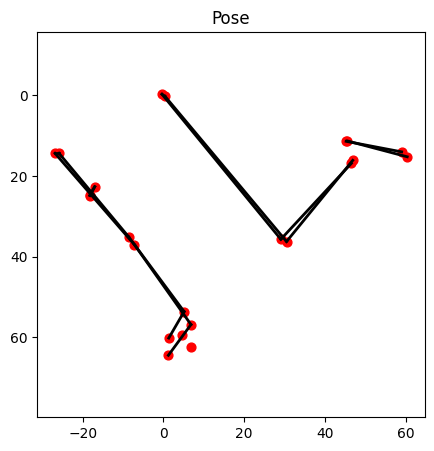

Cat_Cow_Pose (16): true=1, pred=5


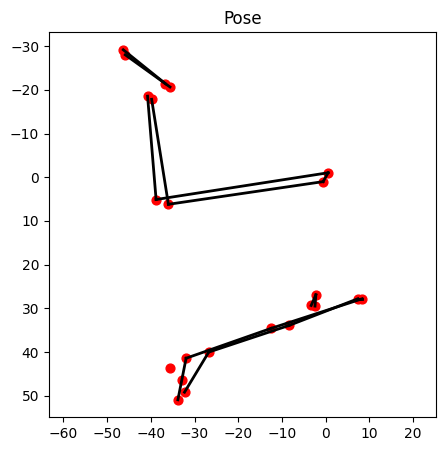

Tree_Pose (23): true=4, pred=0


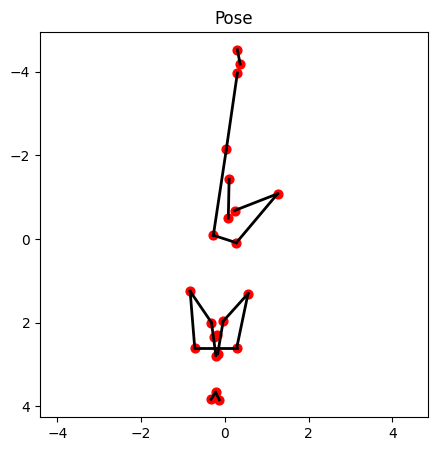

Upward-Facing_Dog_Pose (5): true=6, pred=4


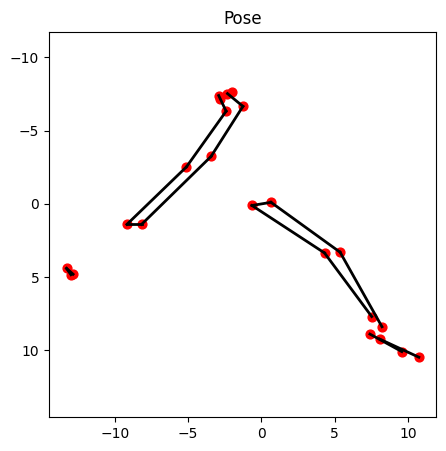

Upward_Bow_Pose (11): true=5, pred=0


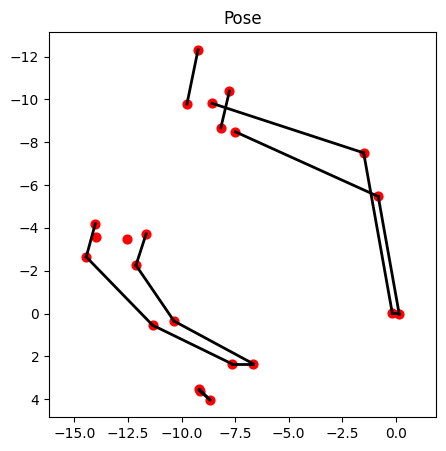

Upward_Bow_Pose (19): true=5, pred=2


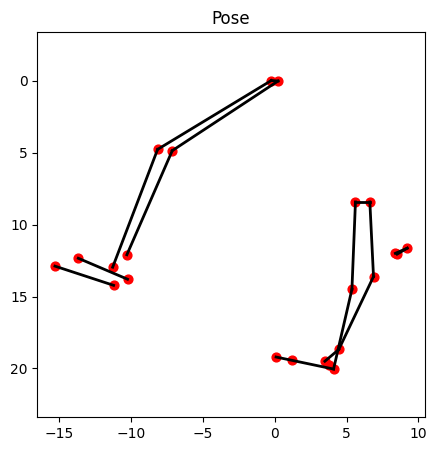

Upward_Bow_Pose (20): true=5, pred=6


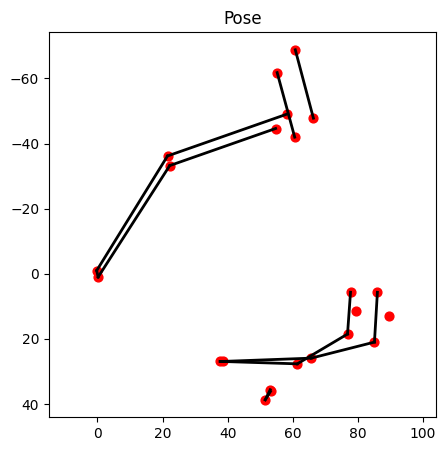

Upward_Bow_Pose (24): true=5, pred=1


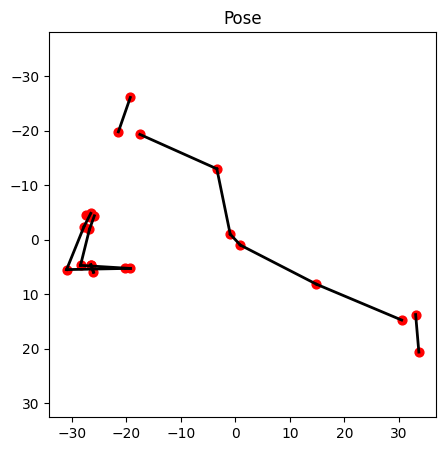

Upward_Bow_Pose (5): true=5, pred=2


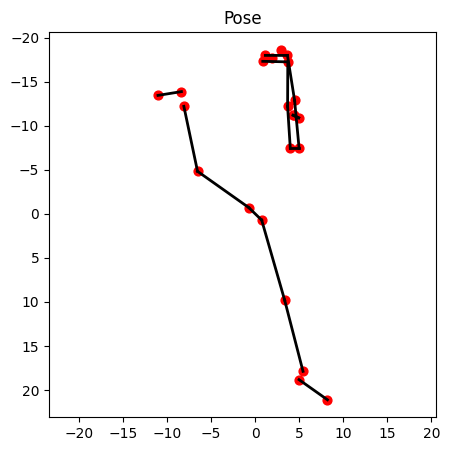

Bound_Angle_Pose (17): true=0, pred=3


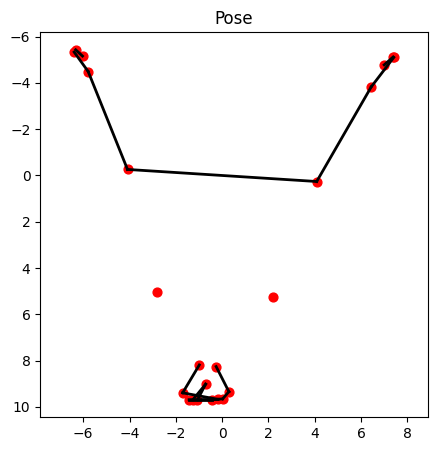

In [22]:
edges = test_npz["edges"]

for i, idx in enumerate(mis_idx[:10]):
    print(f"{img_names[idx]}: true={mis_true[i]}, pred={mis_pred[i]}")
    pose = test_npz["node_features"][idx][:, :2] 
    plot_pose(pose, edges)


In [23]:
# import os

# def plot_and_save_pose(points, edges, save_path, title=""):
#     plt.figure(figsize=(4,4))
#     for (i, j) in edges:
#         plt.plot([points[i,0], points[j,0]], [points[i,1], points[j,1]], 'k-', linewidth=2)
#     plt.scatter(points[:,0], points[:,1], c='red')
#     plt.gca().invert_yaxis()
#     plt.axis('equal')
#     plt.title(title)
#     plt.savefig(save_path)
#     plt.close()

# data = np.load("gcn_dataset_train.npz", allow_pickle=True)
# nodes = data["node_features"]
# edges = data["edges"]
# labels = data["labels"]
# img_names = data["img_names"]  

# os.makedirs("visual_train", exist_ok=True)

# for i in range(len(nodes)):
#     plot_and_save_pose(
#         nodes[i][:,:2],
#         edges,
#         f"visual_train/{i}_{labels[i]}.png",
#         title=f"{img_names[i]} | class={labels[i]}"
#     )


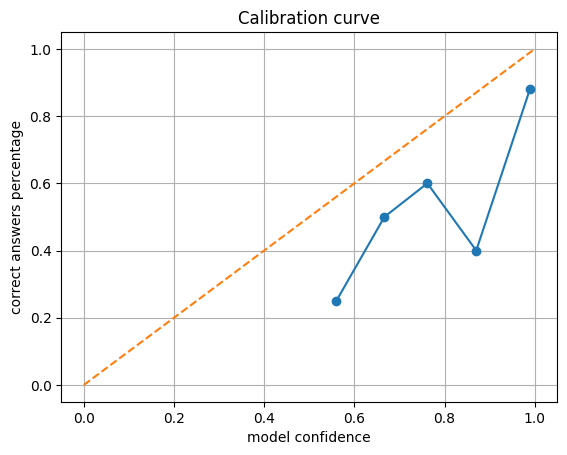

In [24]:
from sklearn.calibration import calibration_curve

model.eval()
all_probs = []
all_true = []

for batch in test_loader:
    out = model(batch.x, batch.edge_index, batch.batch)
    probs = torch.softmax(out, dim=1)
    all_probs.extend(probs.detach().cpu().numpy())
    all_true.extend(batch.y.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

conf = all_probs.max(axis=1)
correct = (all_probs.argmax(axis=1) == all_true).astype(int)

prob_true, prob_pred = calibration_curve(correct, conf, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("model confidence")
plt.ylabel("correct answers percentage")
plt.title("Calibration curve")
plt.grid(True)
plt.show()


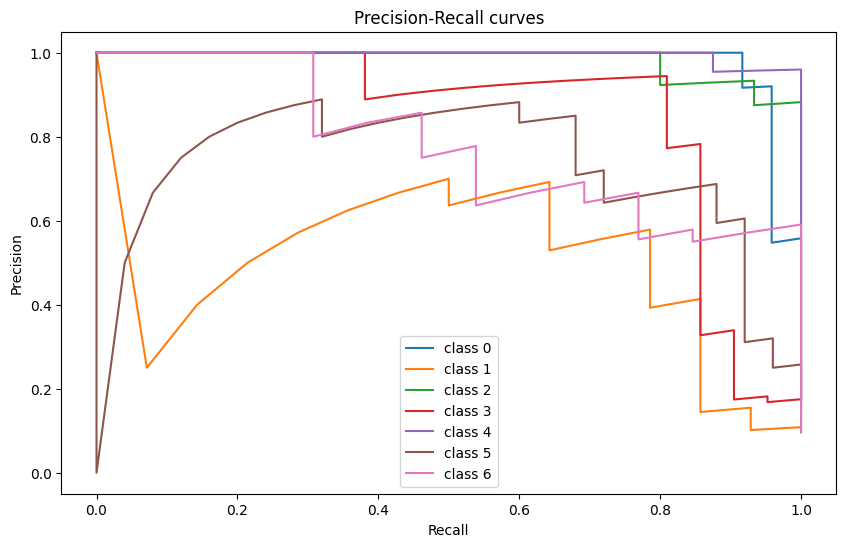

In [25]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

n_classes = len(np.unique(all_true))
y_true_bin = label_binarize(all_true, classes=range(n_classes))

plt.figure(figsize=(10,6))
for c in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:,c], all_probs[:,c])
    plt.plot(recall, precision, label=f"class {c}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision-Recall curves")
plt.show()


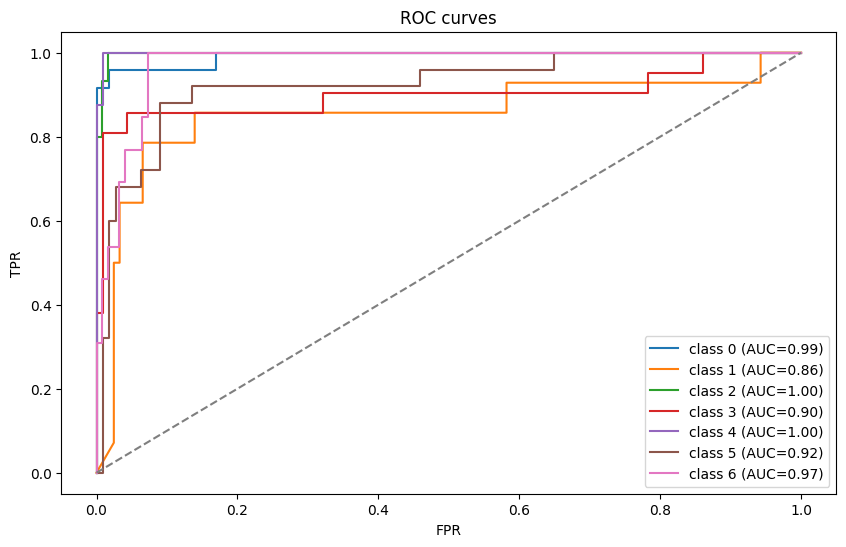

In [26]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,6))
for c in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,c], all_probs[:,c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"class {c} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("ROC curves")
plt.show()


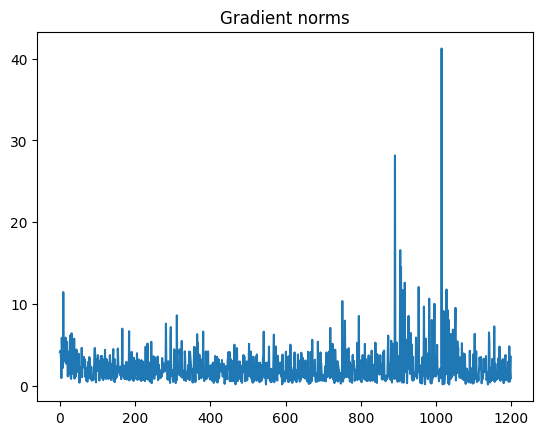

In [27]:
grad_norms = []

for epoch in range(50):
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()

        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()
        grad_norms.append(total_norm)

        optimizer.step()

plt.plot(grad_norms)
plt.title("Gradient norms")
plt.show()


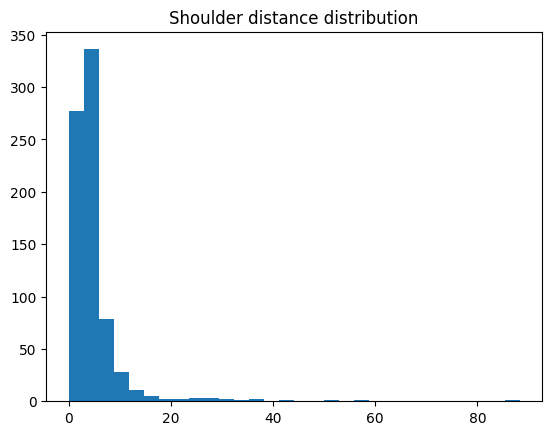

In [ ]:
nodes = train["node_features"]

left_sh = 11
right_sh = 12

dists = []
for pose in nodes:
    p1 = pose[left_sh]
    p2 = pose[right_sh]
    d = np.linalg.norm(p1 - p2)
    dists.append(d)

plt.hist(dists, bins=30)
plt.title("Shoulder distance distribution")
plt.show()


In [ ]:
# diagnostics


for split in ["gcn_dataset_train.npz", "gcn_dataset_valid.npz", "gcn_dataset_test.npz"]:
    d = np.load(split, allow_pickle=True)
    print(split, {k: d[k].shape for k in d.files})
    if "subject" in d.files:
        print(split, "unique subjects:", np.unique(d["subject"]).shape)

d = np.load("gcn_dataset_train.npz", allow_pickle=True)
X = d["node_features"].reshape(len(d["labels"]), -1)  # (N, 23*F)
y = d["labels"]
corr = np.abs(np.corrcoef(X.T, y)[-1, :-1])
print("Top correlated features indices:", np.argsort(-corr)[:10], "values:", np.sort(-corr)[:10])


gcn_dataset_train.npz {'node_features': (755, 23, 6), 'edge_features': (755, 16, 3), 'labels': (755,), 'edges': (16, 2), 'img_names': (755,)}
gcn_dataset_valid.npz {'node_features': (202, 23, 6), 'edge_features': (202, 16, 3), 'edges': (16, 2), 'labels': (202,)}
gcn_dataset_test.npz {'node_features': (136, 23, 6), 'edge_features': (136, 16, 3), 'labels': (136,), 'edges': (16, 2), 'img_names': (136,)}
Top correlated features indices: [101  95  88  35  16  10  94  64 100  58] values: [-0.18808285 -0.18635474 -0.17306149 -0.138049   -0.13707323 -0.13395476
 -0.12535389 -0.12028005 -0.11709853 -0.10923155]


c:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


# MLP, CNN, GCN comparison

In [28]:
class YogaRawDataset(torch.utils.data.Dataset):
    def __init__(self, npz_path):
        data = np.load(npz_path, allow_pickle=True)
        self.node_features = data["node_features"]   # (N, 23, 2)
        self.labels = data["labels"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        coords = torch.tensor(self.node_features[idx], dtype=torch.float)  # (23, 2)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return coords, label


In [29]:
class YogaMLP(nn.Module):
    def __init__(self, num_joints=23, in_features=2, num_classes=6):
        super().__init__()
        input_dim = num_joints * in_features

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # (B, 46)
        return self.net(x)


In [30]:
from PIL import Image, ImageDraw

def pil_to_tensor(img):
    """
    PIL.Image (L) to torch.Tensor (1, H, W)
    """
    arr = np.array(img, dtype=np.float32) / 255.0  # (H, W)
    tensor = torch.tensor(arr).unsqueeze(0)        # (1, H, W)
    return tensor

class YogaImageDataset(torch.utils.data.Dataset):
    def __init__(self, npz_path, img_size=64):
        data = np.load(npz_path, allow_pickle=True)
        self.node_features = data["node_features"]
        self.labels = data["labels"]
        self.img_size = img_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        coords = self.node_features[idx]
        img = skeleton_to_image(coords, self.img_size)
        img = pil_to_tensor(img) 
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

def skeleton_to_image(coords, img_size=64):
    img = Image.new("L", (img_size, img_size), 0)
    draw = ImageDraw.Draw(img)

    x = coords[:, 0]
    y = coords[:, 1]

    x = (x - x.min()) / (x.max() - x.min() + 1e-6)
    y = (y - y.min()) / (y.max() - y.min() + 1e-6)

    x_pix = (x * (img_size - 1)).astype(int)
    y_pix = (y * (img_size - 1)).astype(int)

    for xi, yi in zip(x_pix, y_pix):
        draw.ellipse((xi-2, yi-2, xi+2, yi+2), fill=255)

    return img

class YogaCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [31]:
from torch_geometric.nn import GATv2Conv

class YogaGAT(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, 128, heads=4, concat=False)
        self.conv2 = GATv2Conv(128, 128, heads=4, concat=False)
        self.lin1 = nn.Linear(128, 64)
        self.lin2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = self.lin1(x).relu()
        return self.lin2(x)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [32]:
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool
from torch_geometric.nn import TransformerConv
from torch_geometric.nn import GlobalAttention

class YogaGATPlus(nn.Module):
    def __init__(self, in_channels, num_classes, edge_dim, hidden=256, heads=2, dropout=0.1):
        super().__init__()


        self.conv1 = TransformerConv(in_channels, hidden, heads=4, dropout=0.1, edge_dim=edge_dim, concat=False)
        self.conv2 = TransformerConv(hidden, hidden, heads=4, dropout=0.1, edge_dim=edge_dim, concat=False)


        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.lin1 = nn.Linear(hidden * 3, 64)
        self.lin2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.att_pool = GlobalAttention(gate_nn=nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ))

    def forward(self, x, edge_index, batch, edge_attr=None):
        h0 = x

        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = F.relu(self.bn1(x))
        x = self.dropout(x)

        if h0.shape[-1] == x.shape[-1]:
            x = x + h0

        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = F.relu(self.bn2(x))
        x = self.dropout(x)

        # pooling
        x_att = self.att_pool(x, batch)
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)

        x = torch.cat([x_att, x_mean, x_max], dim=1)

        x = F.relu(self.lin1(x))
        x = self.dropout(x)
        return self.lin2(x)



In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from torch_geometric.utils import dropout_edge


class YogaGCN(nn.Module):
    def __init__(self, in_channels, num_classes, hidden=128, dropout=0.1, dropedge=0.1):
        super().__init__()

        self.dropedge = dropedge

        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)

        self.ln1 = nn.LayerNorm(hidden)
        self.ln2 = nn.LayerNorm(hidden)

        self.lin1 = nn.Linear(hidden * 2, 64)
        self.lin2 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch):
        # DropEdge — стабилизирует граф
        edge_index, _ = dropout_edge(edge_index, p=self.dropedge, training=self.training)

        # conv1
        x = self.conv1(x, edge_index)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # conv2
        x = self.conv2(x, edge_index)
        x = self.ln2(x)
        x = F.relu(x)
        x = self.dropout(x)

        # readout: mean + max
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        x = F.relu(self.lin1(x))
        x = self.dropout(x)
        return self.lin2(x)


In [34]:
# def train_epoch(model, loader, optimizer, device):
#     model.train()
#     total_loss, total_correct, total_samples = 0, 0, 0
#     criterion = nn.CrossEntropyLoss()

#     for batch in loader:
#         optimizer.zero_grad()

#         if isinstance(batch, Data):  # GCN
#             batch = batch.to(device)
#             out = model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
#             y = batch.y
#         else:  # MLP / CNN
#             x, y = batch
#             x, y = x.to(device), y.to(device)
#             out = model(x)

#         loss = criterion(out, y)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * y.size(0)
#         total_correct += (out.argmax(1) == y).sum().item()
#         total_samples += y.size(0)

#     return total_loss / total_samples, total_correct / total_samples


# @torch.no_grad()
# def eval_epoch(model, loader, device):
#     model.eval()
#     total_loss, total_correct, total_samples = 0, 0, 0
#     criterion = nn.CrossEntropyLoss()

#     for batch in loader:
#         if isinstance(batch, Data):
#             batch = batch.to(device)
#             out = model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
#             y = batch.y
#         else:
#             x, y = batch
#             x, y = x.to(device), y.to(device)
#             out = model(x)

#         loss = criterion(out, y)
#         total_loss += loss.item() * y.size(0)
#         total_correct += (out.argmax(1) == y).sum().item()
#         total_samples += y.size(0)

#     return total_loss / total_samples, total_correct / total_samples


In [35]:
# def train_epoch(model, loader, optimizer, device, criterion, is_graph_model=False, max_grad_norm=1.0):
#     model.train()
#     total_loss, total_correct, total_samples = 0.0, 0, 0

#     for batch in loader:
#         optimizer.zero_grad()

#         if is_graph_model:
#             batch = batch.to(device)
#             out = model(batch.x, batch.edge_index, batch.batch)
#             y = batch.y.to(device)
#         else:
#             x, y = batch
#             x, y = x.to(device), y.to(device)
#             out = model(x)

#         loss = criterion(out, y)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
#         optimizer.step()

#         total_loss += loss.item() * y.size(0)
#         total_correct += (out.argmax(1) == y).sum().item()
#         total_samples += y.size(0)

#     return total_loss / total_samples, total_correct / total_samples


# @torch.no_grad()
# def eval_epoch(model, loader, device, criterion, is_graph_model=False):
#     model.eval()
#     total_loss, total_correct, total_samples = 0.0, 0, 0

#     for batch in loader:
#         if is_graph_model:
#             batch = batch.to(device)
#             out = model(batch.x, batch.edge_index, batch.batch)
#             y = batch.y.to(device)
#         else:
#             x, y = batch
#             x, y = x.to(device), y.to(device)
#             out = model(x)

#         loss = criterion(out, y)
#         total_loss += loss.item() * y.size(0)
#         total_correct += (out.argmax(1) == y).sum().item()
#         total_samples += y.size(0)

#     return total_loss / total_samples, total_correct / total_samples


In [36]:
def train_epoch(model, loader, optimizer, device, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for batch in loader:
        if isinstance(batch, Data):
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            y = batch.y
        else:
            x, y = batch
            x, y = x.to(device), y.to(device)
            out = model(x)

        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def eval_epoch(model, loader, device, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for batch in loader:
        if isinstance(batch, Data):
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            y = batch.y
        else:
            x, y = batch
            x, y = x.to(device), y.to(device)
            out = model(x)

        loss = criterion(out, y)
        total_loss += loss.item() * y.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples



In [ ]:
from torch.utils.data import WeightedRandomSampler
from torch_geometric.loader import DataLoader as GeoDataLoader



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_dim = train_ds[0].edge_attr.shape[1] 


# GCN 

gcn_model = YogaGCN(
    in_channels=6,
    num_classes=len(np.unique(labels)),
    hidden=128,
    dropout=0.1,
    dropedge=0.1
).to(device)

gcn_opt = torch.optim.Adam(
    gcn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)



# MLP
mlp_train = DataLoader(YogaRawDataset("gcn_dataset_train.npz"), batch_size=32, shuffle=True)
mlp_valid = DataLoader(YogaRawDataset("gcn_dataset_valid.npz"), batch_size=32)
mlp_test  = DataLoader(YogaRawDataset("gcn_dataset_test.npz"), batch_size=32)

mlp_model = YogaMLP(
    num_joints=23,
    in_features=node_features.shape[-1],
    num_classes=len(np.unique(labels))
).to(device)
mlp_opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-4)

# CNN 
cnn_train = DataLoader(YogaImageDataset("gcn_dataset_train.npz"), batch_size=32, shuffle=True)
cnn_valid = DataLoader(YogaImageDataset("gcn_dataset_valid.npz"), batch_size=32)
cnn_test  = DataLoader(YogaImageDataset("gcn_dataset_test.npz"), batch_size=32)

cnn_model = YogaCNN(num_classes=len(np.unique(labels))).to(device)
cnn_opt = torch.optim.Adam(cnn_model.parameters(), lr=1e-4)


labels_train = train_ds.labels
classes, counts = np.unique(labels_train, return_counts=True)
class_weights = {c: 1.0 / counts[i] for i, c in enumerate(classes)}
sample_weights = np.array([class_weights[int(l)] for l in labels_train], dtype=np.float32)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = GeoDataLoader(train_ds, batch_size=32, sampler=sampler)
valid_loader = GeoDataLoader(valid_ds, batch_size=32)
test_loader  = GeoDataLoader(test_ds,  batch_size=32)


criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gcn_opt, mode='max', factor=0.5, patience=10)


In [38]:
# d = np.load("gcn_dataset_train.npz", allow_pickle=True)
# orig_in = d["node_features"].shape[-1]   # 6
# edge_dim = d["edge_features"].shape[-1]  # 3
# num_classes = len(np.unique(d["labels"]))

# in_channels = orig_in + edge_dim  # важно!

#gcn_model = YogaGATPlus(in_channels=in_channels, num_classes=num_classes, hidden=128, heads=4, dropout=0.1).to(device)

# from sklearn.utils.class_weight import compute_class_weight
# train_labels = d["labels"]
# cw = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
# class_weights = torch.tensor(cw, dtype=torch.float).to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)

# # optimizers с weight decay
# gcn_opt = torch.optim.Adam(gcn_model.parameters(), lr=1e-4, weight_decay=1e-5)
# mlp_opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-4, weight_decay=1e-5)
# cnn_opt = torch.optim.Adam(cnn_model.parameters(), lr=1e-4, weight_decay=1e-5)

# # schedulers без verbose
# gcn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gcn_opt, mode="max", factor=0.5, patience=6)
# mlp_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(mlp_opt, mode="max", factor=0.5, patience=6)
# cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(cnn_opt, mode="max", factor=0.5, patience=6)



In [39]:
b = next(iter(train_loader))
print("edge_attr shape:", b.edge_attr.shape)


print(hasattr(b, "edge_attr"), b.edge_attr is None)


edge_attr shape: torch.Size([512, 3])
True False


In [40]:
history = {
    "epoch": [],
    "gcn_val": [],
    "mlp_val": [],
    "cnn_val": []
}

for epoch in range(1, 201):
    # GAT
    gcn_tr_loss, gcn_tr_acc = train_epoch(gcn_model, train_loader, gcn_opt, device, criterion)
    gcn_val_loss, gcn_val_acc = eval_epoch(gcn_model, valid_loader, device, criterion)

    # MLP
    mlp_tr_loss, mlp_tr_acc = train_epoch(mlp_model, mlp_train, mlp_opt, device, criterion)
    mlp_val_loss, mlp_val_acc = eval_epoch(mlp_model, mlp_valid, device, criterion)

    # CNN
    cnn_tr_loss, cnn_tr_acc = train_epoch(cnn_model, cnn_train, cnn_opt, device, criterion)
    cnn_val_loss, cnn_val_acc = eval_epoch(cnn_model, cnn_valid, device, criterion)

    history["epoch"].append(epoch)
    history["gcn_val"].append(gcn_val_acc)
    history["mlp_val"].append(mlp_val_acc)
    history["cnn_val"].append(cnn_val_acc)

    print(f"Epoch {epoch:03d} | "
          f"GCN val_acc={gcn_val_acc:.3f} | "
          f"MLP val_acc={mlp_val_acc:.3f} | "
          f"CNN val_acc={cnn_val_acc:.3f}")
    
    


Epoch 001 | GCN val_acc=0.251 | MLP val_acc=0.183 | CNN val_acc=0.188
Epoch 002 | GCN val_acc=0.394 | MLP val_acc=0.188 | CNN val_acc=0.317
Epoch 003 | GCN val_acc=0.414 | MLP val_acc=0.228 | CNN val_acc=0.381
Epoch 004 | GCN val_acc=0.438 | MLP val_acc=0.272 | CNN val_acc=0.431
Epoch 005 | GCN val_acc=0.433 | MLP val_acc=0.287 | CNN val_acc=0.455
Epoch 006 | GCN val_acc=0.345 | MLP val_acc=0.322 | CNN val_acc=0.480
Epoch 007 | GCN val_acc=0.379 | MLP val_acc=0.302 | CNN val_acc=0.480
Epoch 008 | GCN val_acc=0.409 | MLP val_acc=0.292 | CNN val_acc=0.530
Epoch 009 | GCN val_acc=0.532 | MLP val_acc=0.337 | CNN val_acc=0.520
Epoch 010 | GCN val_acc=0.601 | MLP val_acc=0.361 | CNN val_acc=0.579
Epoch 011 | GCN val_acc=0.517 | MLP val_acc=0.366 | CNN val_acc=0.559
Epoch 012 | GCN val_acc=0.567 | MLP val_acc=0.376 | CNN val_acc=0.584
Epoch 013 | GCN val_acc=0.596 | MLP val_acc=0.381 | CNN val_acc=0.579
Epoch 014 | GCN val_acc=0.596 | MLP val_acc=0.391 | CNN val_acc=0.599
Epoch 015 | GCN val_

In [41]:
b = next(iter(train_loader))
print("edge_attr shape:", b.edge_attr.shape)


edge_attr shape: torch.Size([512, 3])


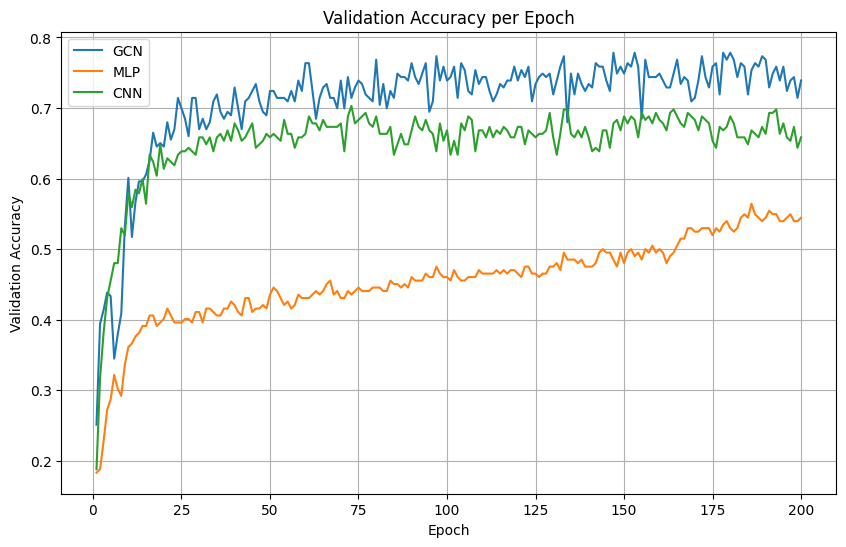

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(history["epoch"], history["gcn_val"], label="GCN")
plt.plot(history["epoch"], history["mlp_val"], label="MLP")
plt.plot(history["epoch"], history["cnn_val"], label="CNN")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


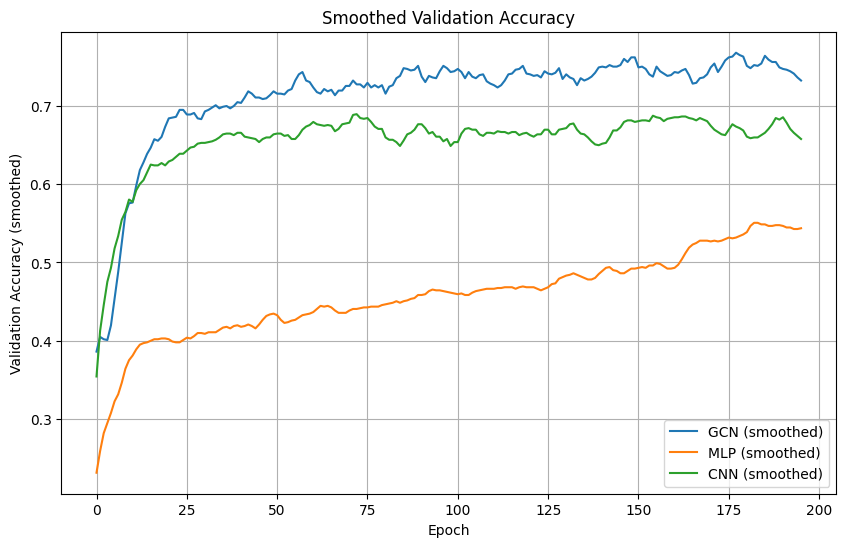

In [43]:
def smooth(values, window=5):
    return np.convolve(values, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 6))
plt.plot(smooth(history["gcn_val"]), label="GCN (smoothed)")
plt.plot(smooth(history["mlp_val"]), label="MLP (smoothed)")
plt.plot(smooth(history["cnn_val"]), label="CNN (smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (smoothed)")
plt.title("Smoothed Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [44]:
best_gcn_epoch = np.argmax(history["gcn_val"]) + 1
best_mlp_epoch = np.argmax(history["mlp_val"]) + 1
best_cnn_epoch = np.argmax(history["cnn_val"]) + 1

print("Лучшие эпохи:")
print(f"GCN: epoch {best_gcn_epoch}, val_acc={history['gcn_val'][best_gcn_epoch-1]:.3f}")
print(f"MLP: epoch {best_mlp_epoch}, val_acc={history['mlp_val'][best_mlp_epoch-1]:.3f}")
print(f"CNN: epoch {best_cnn_epoch}, val_acc={history['cnn_val'][best_cnn_epoch-1]:.3f}")


Лучшие эпохи:
GCN: epoch 147, val_acc=0.778
MLP: epoch 186, val_acc=0.564
CNN: epoch 73, val_acc=0.703


In [68]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gcn_opt, mode='max', factor=0.5, patience=10)

gcn_model = YogaGCN(
    in_channels=6,
    num_classes=len(np.unique(labels)),
    hidden=256,
    dropout=0.1,
    dropedge=0.1
).to(device)

gcn_opt = torch.optim.Adam(
    gcn_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)



history = {
    "epoch": [],
    "gcn_val": [],
    "mlp_val": [],
    "cnn_val": []
}

for epoch in range(1, 201):
    # GAT
    gcn_tr_loss, gcn_tr_acc = train_epoch(gcn_model, train_loader, gcn_opt, device, criterion)
    gcn_val_loss, gcn_val_acc = eval_epoch(gcn_model, valid_loader, device, criterion)

    
    cnn_val_loss, cnn_val_acc = eval_epoch(cnn_model, cnn_valid, device, criterion)

    history["epoch"].append(epoch)
    history["gcn_val"].append(gcn_val_acc)


    print(f"Epoch {epoch:03d} | "
          f"GCN val_acc={gcn_val_acc:.3f}")

Epoch 001 | GCN val_acc=0.133
Epoch 002 | GCN val_acc=0.360
Epoch 003 | GCN val_acc=0.281
Epoch 004 | GCN val_acc=0.330
Epoch 005 | GCN val_acc=0.325
Epoch 006 | GCN val_acc=0.389
Epoch 007 | GCN val_acc=0.335
Epoch 008 | GCN val_acc=0.300
Epoch 009 | GCN val_acc=0.320
Epoch 010 | GCN val_acc=0.335
Epoch 011 | GCN val_acc=0.399
Epoch 012 | GCN val_acc=0.320
Epoch 013 | GCN val_acc=0.478
Epoch 014 | GCN val_acc=0.360
Epoch 015 | GCN val_acc=0.498
Epoch 016 | GCN val_acc=0.369
Epoch 017 | GCN val_acc=0.394
Epoch 018 | GCN val_acc=0.488
Epoch 019 | GCN val_acc=0.365
Epoch 020 | GCN val_acc=0.384
Epoch 021 | GCN val_acc=0.542
Epoch 022 | GCN val_acc=0.438
Epoch 023 | GCN val_acc=0.498
Epoch 024 | GCN val_acc=0.399
Epoch 025 | GCN val_acc=0.399
Epoch 026 | GCN val_acc=0.404
Epoch 027 | GCN val_acc=0.389
Epoch 028 | GCN val_acc=0.394
Epoch 029 | GCN val_acc=0.448
Epoch 030 | GCN val_acc=0.483
Epoch 031 | GCN val_acc=0.438
Epoch 032 | GCN val_acc=0.424
Epoch 033 | GCN val_acc=0.468
Epoch 034 

Test Accuracy: 0.8235294117647058
Confusion Matrix:
[[22  0  0  2  0  0  0]
 [ 0  9  1  0  0  3  1]
 [ 0  0 14  0  0  1  0]
 [ 0  3  0 18  0  0  0]
 [ 0  0  0  0 24  0  0]
 [ 0  1  4  0  0 20  0]
 [ 2  4  0  0  1  1  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        24
           1       0.53      0.64      0.58        14
           2       0.74      0.93      0.82        15
           3       0.90      0.86      0.88        21
           4       0.96      1.00      0.98        24
           5       0.80      0.80      0.80        25
           6       0.83      0.38      0.53        13

    accuracy                           0.82       136
   macro avg       0.81      0.79      0.79       136
weighted avg       0.83      0.82      0.82       136



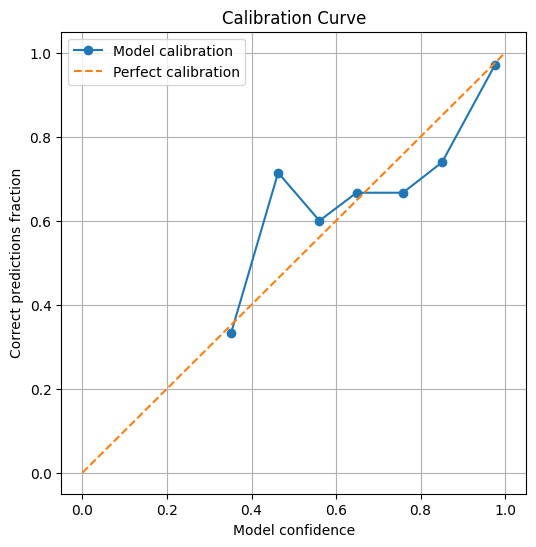

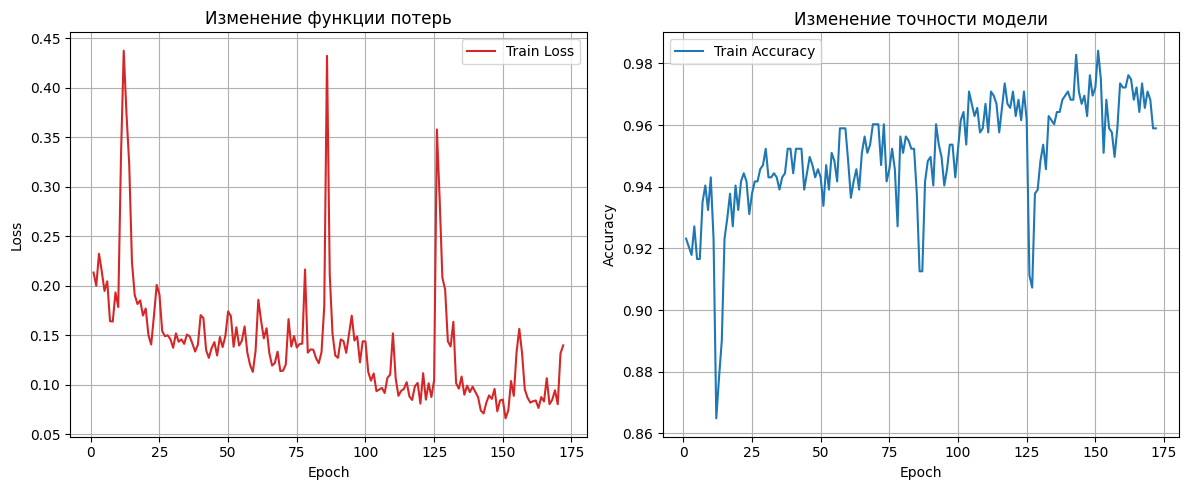

In [69]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve

gcn_model.eval()


correct = 0

for batch in test_loader:
    batch = batch.to(device)
    out = gcn_model(batch.x, batch.edge_index, batch.batch)
    pred = out.argmax(dim=1)
    correct += (pred == batch.y).sum().item()

test_acc = correct / len(test_ds)
print("Test Accuracy:", test_acc)



all_preds = []
all_true = []

gcn_model.eval()
for batch in test_loader:
    batch = batch.to(device)
    out = gcn_model(batch.x, batch.edge_index, batch.batch)
    preds = out.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_true.extend(batch.y.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_true, all_preds))



gcn_model.eval()
all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)
    out = gcn_model(batch.x, batch.edge_index, batch.batch)
    probs = torch.softmax(out, dim=1)
    all_probs.extend(probs.detach().cpu().numpy())
    all_true.extend(batch.y.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

conf = all_probs.max(axis=1)
correct_flags = (all_probs.argmax(axis=1) == all_true).astype(int)

prob_true, prob_pred = calibration_curve(correct_flags, conf, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label="Model calibration")
plt.plot([0,1],[0,1],'--', label="Perfect calibration")
plt.xlabel("Model confidence")
plt.ylabel("Correct predictions fraction")
plt.title("Calibration Curve")
plt.grid(True)
plt.legend()
plt.show()



epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, label="Train Loss", color="tab:red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_history, label="Train Accuracy", color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Изменение точности модели")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_true = []

gcn_model.eval()
for batch in test_loader:
    out = model(batch.x, batch.edge_index, batch.batch)
    preds = out.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_true.extend(batch.y.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)
print(cm)
print(classification_report(all_true, all_preds))

TypeError: YogaMLP.forward() takes 2 positional arguments but 4 were given

In [70]:
pip install torchinfo


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
from torchinfo import summary
summary(gcn_model)


Layer (type:depth-idx)                   Param #
YogaGCN                                  --
├─GCNConv: 1-1                           256
│    └─SumAggregation: 2-1               --
│    └─Linear: 2-2                       1,536
├─GCNConv: 1-2                           256
│    └─SumAggregation: 2-3               --
│    └─Linear: 2-4                       65,536
├─LayerNorm: 1-3                         512
├─LayerNorm: 1-4                         512
├─Linear: 1-5                            32,832
├─Linear: 1-6                            455
├─Dropout: 1-7                           --
Total params: 101,895
Trainable params: 101,895
Non-trainable params: 0

In [78]:
import torch

model = gcn_model.eval()   


x = torch.randn(23, 6).to("cpu")
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to("cpu")

batch = torch.zeros(23, dtype=torch.long).to("cpu")  # один граф

scripted = torch.jit.trace(model, (x, edge_index, batch))

scripted.save("yoga_gcn.pt")
print("Saved as yoga_gcn.pt")


Saved as yoga_gcn.pt
